# RO6: Efficiency and Practicality Trade-off Analysis
This notebook analyzes the trade-offs between Gemini 3.0 Flash (0-shot) and the specialized SLM (Pass@1 and Pass@5).

C:\Users\User\AppData\Local\Temp\ipykernel_9976\428705458.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x="Method", y="Accuracy (%)", data=df_standard, palette=colors_3)


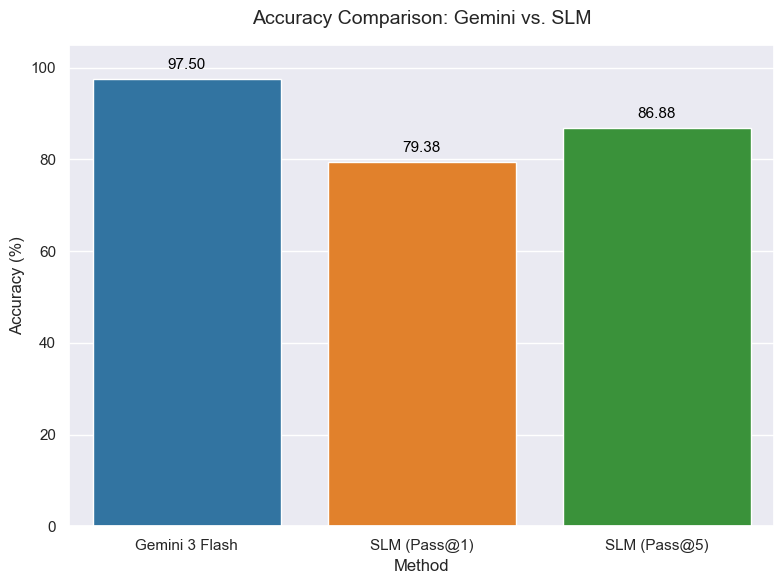

C:\Users\User\AppData\Local\Temp\ipykernel_9976\428705458.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x="Method", y="Latency (s)", data=df_standard, palette=colors_3)


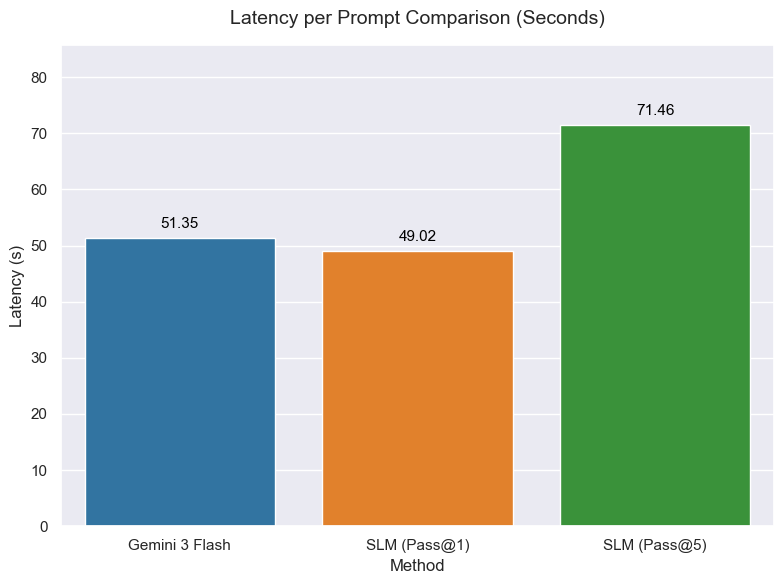

C:\Users\User\AppData\Local\Temp\ipykernel_9976\428705458.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.barplot(x="Method", y="Output Tokens", data=df_standard, palette=colors_3)


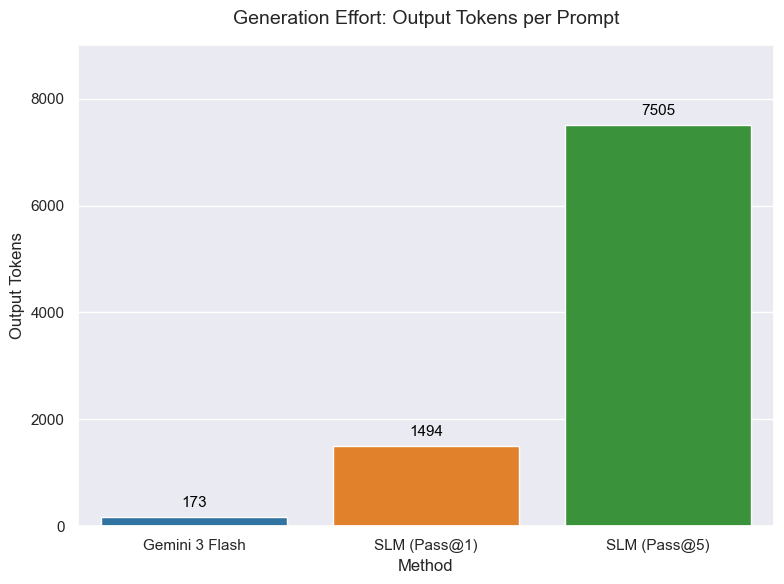

C:\Users\User\AppData\Local\Temp\ipykernel_9976\428705458.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax4 = sns.barplot(x="Method", y="Cost per 100 ($)", data=df_cost, palette=colors_4)


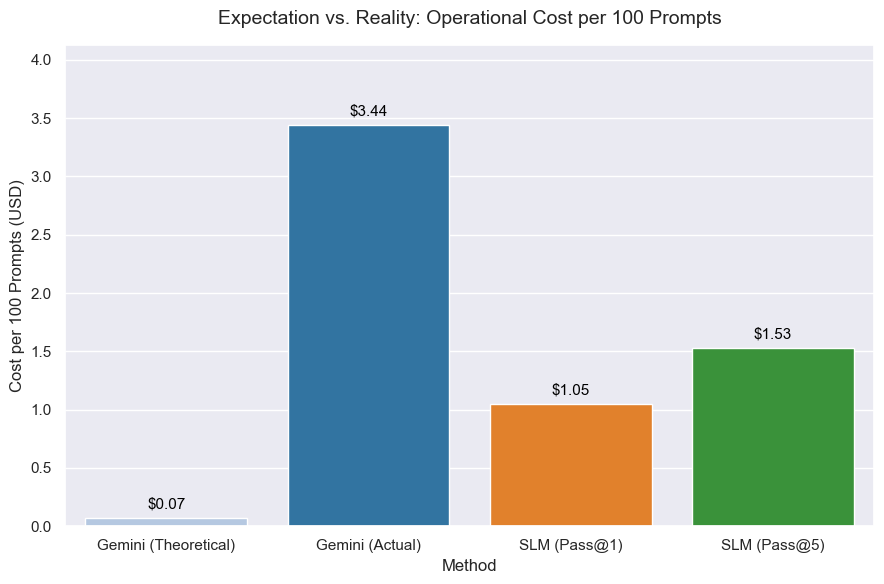

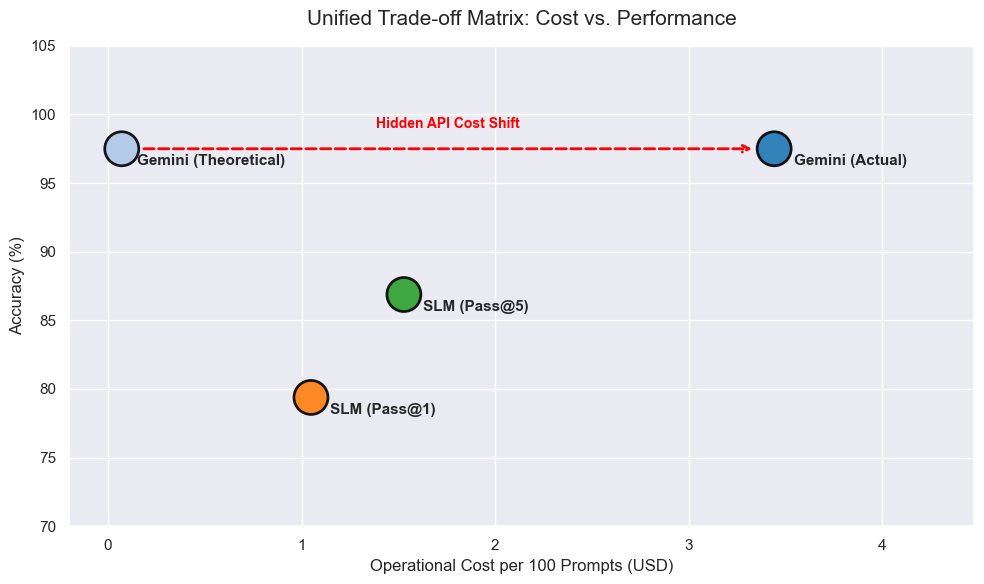

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# ==========================================
# 1. Load Key Metrics (From RO5 Evaluation)
# ==========================================
with open('../../ro5_comparative-evaluation/data/gemini3-flash/gemini3_evaluation_results.json', 'r') as f:
    gemini_data = json.load(f)['summary']
with open('../../ro5_comparative-evaluation/data/qwen2.5-7b/qwen2.5_evaluation_results.json', 'r') as f:
    qwen_data = json.load(f)['summary']

# Accuracy (%)
acc_gemini = gemini_data['Total_Accuracy_%']
acc_slm_pass1 = qwen_data['Total_Pass@1_Accuracy_%']
acc_slm_pass5 = qwen_data['Total_Pass@5_Accuracy_%']

# Latency (Seconds per prompt)
lat_gemini = gemini_data['Avg_Latency_s']
lat_slm_pass1 = qwen_data['Avg_Latency_Pass1_s']
lat_slm_pass5 = qwen_data['Avg_Latency_Pass5_s']

# Output Tokens per prompt
tok_gemini = gemini_data['Avg_Output_Tokens']
tok_slm_pass1 = qwen_data['Avg_Output_Tokens_Pass1']
tok_slm_pass5 = qwen_data['Avg_Output_Tokens_per_attempt_Pass5'] * 5 # Pass@5 generates 5 sequences

# API Pricing & GPU Costs
GEMINI_INPUT_COST_PER_M = 0.50  # $0.50 per 1M input tokens
GEMINI_OUTPUT_COST_PER_M = 3.00 # $3.00 per 1M output tokens
GPU_HOURLY_RATE = 0.77          # RunPod RTX 6000 Ada
EXCHANGE_RATE = 4.00            # 1 USD = 4.00 RM

# ==========================================
# 2. Cost Calculations (Per 100 Prompts)
# ==========================================
# --- THEORETICAL COST ---
gemini_avg_in = gemini_data['Avg_Input_Tokens']
gemini_avg_out = gemini_data['Avg_Output_Tokens']
cost_gemini_theo = (((gemini_avg_in * 100) / 1_000_000) * GEMINI_INPUT_COST_PER_M) + \
                   (((gemini_avg_out * 100) / 1_000_000) * GEMINI_OUTPUT_COST_PER_M)

# --- ACTUAL COST ---
gemini_total_usd = 22.02 / EXCHANGE_RATE  
cost_gemini_actual = (gemini_total_usd / 160) * 100  # Cost per 100 prompts

# --- SLM COST ---
cost_slm_pass1 = (lat_slm_pass1 / 3600) * 100 * GPU_HOURLY_RATE  
cost_slm_pass5 = (lat_slm_pass5 / 3600) * 100 * GPU_HOURLY_RATE  

# ==========================================
# 3. DataFrames Construction
# ==========================================
# DataFrame for Charts 1, 2, 3
df_standard = pd.DataFrame({
    "Method": ["Gemini 3 Flash", "SLM (Pass@1)", "SLM (Pass@5)"],
    "Accuracy (%)": [acc_gemini, acc_slm_pass1, acc_slm_pass5],
    "Latency (s)": [lat_gemini, lat_slm_pass1, lat_slm_pass5],
    "Output Tokens": [tok_gemini, tok_slm_pass1, tok_slm_pass5]
})

# DataFrame for Chart 4 (4 Bars total)
df_cost = pd.DataFrame({
    "Method": ["Gemini (Theoretical)", "Gemini (Actual)", "SLM (Pass@1)", "SLM (Pass@5)"],
    "Cost per 100 ($)": [cost_gemini_theo, cost_gemini_actual, cost_slm_pass1, cost_slm_pass5]
})

# ==========================================
# 4. Data Visualization Setup
# ==========================================
sns.set_theme(style="darkgrid")
colors_3 = ["#1f77b4", "#ff7f0e", "#2ca02c"] # Blue, Orange, Green
colors_4 = ["#aec7e8", "#1f77b4", "#ff7f0e", "#2ca02c"] # Light Blue, Dark Blue, Orange, Green

def add_bar_labels(ax, format_str='{:.2f}'):
    for p in ax.patches:
        ax.annotate(format_str.format(p.get_height()), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', 
                    fontsize=11, color='black', xytext=(0, 5), 
                    textcoords='offset points')


# --- Chart 2: Latency Comparison ---
plt.figure(figsize=(8, 6))
ax2 = sns.barplot(x="Method", y="Latency (s)", data=df_standard, palette=colors_3)
plt.title("Latency per Prompt Comparison (Seconds)", fontsize=14, pad=15)
plt.ylim(0, df_standard["Latency (s)"].max() * 1.2)
add_bar_labels(ax2)
plt.tight_layout()
plt.savefig("RO6_Latency_Comparison.png", dpi=300)
plt.show()

# --- Chart 3: Token Usage Comparison ---
plt.figure(figsize=(8, 6))
ax3 = sns.barplot(x="Method", y="Output Tokens", data=df_standard, palette=colors_3)
plt.title("Generation Effort: Output Tokens per Prompt", fontsize=14, pad=15)
plt.ylim(0, df_standard["Output Tokens"].max() * 1.2)
add_bar_labels(ax3, format_str='{:.0f}')
plt.tight_layout()
plt.savefig("RO6_Tokens_Comparison.png", dpi=300)
plt.show()

# --- Chart 4: Unified Financial Cost Comparison ---
plt.figure(figsize=(9, 6))
ax4 = sns.barplot(x="Method", y="Cost per 100 ($)", data=df_cost, palette=colors_4)
plt.title("Expectation vs. Reality: Operational Cost per 100 Prompts", fontsize=14, pad=15)
plt.ylabel("Cost per 100 Prompts (USD)", fontsize=12)
plt.ylim(0, df_cost["Cost per 100 ($)"].max() * 1.2)
add_bar_labels(ax4, format_str='${:.2f}')
plt.tight_layout()
plt.savefig("RO6_Combined_Cost_Chart.png", dpi=300)
plt.show()

# --- Chart 5: The Trade-off Matrix (Scatter Plot) ---
plt.figure(figsize=(10, 6))
methods = ["Gemini (Theoretical)", "Gemini (Actual)", "SLM (Pass@1)", "SLM (Pass@5)"]
costs = [cost_gemini_theo, cost_gemini_actual, cost_slm_pass1, cost_slm_pass5]
accs = [acc_gemini, acc_gemini, acc_slm_pass1, acc_slm_pass5]

sns.scatterplot(x=costs, y=accs, hue=methods, palette=colors_4, s=600, alpha=0.9, edgecolor="black", legend=False)

# Add text labels next to bubbles
for i in range(len(methods)):
    offset_x = 0.08 if "Gemini (Theoretical)" in methods[i] else 0.1
    plt.text(costs[i] + offset_x, accs[i] - 1.2, methods[i], fontsize=11, fontweight='bold')

# Draw an arrow showing the "Hidden Cost Shift" for Gemini
plt.annotate("", xy=(cost_gemini_actual - 0.1, acc_gemini), xytext=(cost_gemini_theo + 0.1, acc_gemini),
             arrowprops=dict(arrowstyle="->", color="red", lw=2, ls="--"))
plt.text((cost_gemini_theo + cost_gemini_actual) / 2, acc_gemini + 1.5, "Hidden API Cost Shift", 
         color="red", fontsize=10, ha='center', fontweight='bold')

plt.title("Unified Trade-off Matrix: Cost vs. Performance", fontsize=15, pad=15)
plt.xlabel("Operational Cost per 100 Prompts (USD)", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.xlim(-0.2, max(costs) * 1.3)
plt.ylim(70, 105)
plt.tight_layout()
plt.savefig("RO6_Combined_Tradeoff_Matrix.png", dpi=300)
plt.show()